# Lab | Data Structuring and Combining Data

## Challenge 1: Combining & Cleaning Data

In this challenge, we will be working with the customer data from an insurance company, as we did in the two previous labs. The data can be found here:
- https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file1.csv

But this time, we got new data, which can be found in the following 2 CSV files located at the links below.

- https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file2.csv
- https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file3.csv

Note that you'll need to clean and format the new data.

Observation:
- One option is to first combine the three datasets and then apply the cleaning function to the new combined dataset
- Another option would be to read the clean file you saved in the previous lab, and just clean the two new files and concatenate the three clean datasets

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [108]:
url = 'https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file1.csv'
url1 = 'http://raw.githubusercontent.com/data-bootcamp-v4/data/main/file2.csv'
url2 = 'https://raw.githubusercontent.com/data-bootcamp-v4/data/main/file3.csv'

insurance_df = pd.read_csv(url)
df1 = pd.read_csv(url1)
df2 = pd.read_csv(url2)

In [109]:
insurance_df.head()

,Customer,ST,GENDER,Education,Customer Lifetime Value,Income,Monthly Premium Auto,Number of Open Complaints,Policy Type,Vehicle Class,Total Claim Amount
0,RB50392,Washington,NaN,Master,NaN,0.0,1000.0,1/0/00,Personal Auto,Four-Door Car,2.704934
1,QZ44356,Arizona,F,Bachelor,697953.59%,0.0,94.0,1/0/00,Personal Auto,Four-Door Car,1131.464935
2,AI49188,Nevada,F,Bachelor,1288743.17%,48767.0,108.0,1/0/00,Personal Auto,Two-Door Car,566.472247
3,WW63253,California,M,Bachelor,764586.18%,0.0,106.0,1/0/00,Corporate Auto,SUV,529.881344
4,GA49547,Washington,M,High School or Below,536307.65%,36357.0,68.0,1/0/00,Personal Auto,Four-Door Car,17.269323


In [110]:
# changing ST to state
insurance_df= insurance_df.rename(columns={'ST': 'state'})
insurance_df

# Formatting the remaining column
insurance_df.columns = insurance_df.columns.str.lower().str.replace(' ', '_')
insurance_df


,customer,state,gender,education,customer_lifetime_value,income,monthly_premium_auto,number_of_open_complaints,policy_type,vehicle_class,total_claim_amount
0,RB50392,Washington,NaN,Master,NaN,0.0,1000.0,1/0/00,Personal Auto,Four-Door Car,2.704934
1,QZ44356,Arizona,F,Bachelor,697953.59%,0.0,94.0,1/0/00,Personal Auto,Four-Door Car,1131.464935
2,AI49188,Nevada,F,Bachelor,1288743.17%,48767.0,108.0,1/0/00,Personal Auto,Two-Door Car,566.472247
3,WW63253,California,M,Bachelor,764586.18%,0.0,106.0,1/0/00,Corporate Auto,SUV,529.881344
4,GA49547,Washington,M,High School or Below,536307.65%,36357.0,68.0,1/0/00,Personal Auto,Four-Door Car,17.269323
...,...,...,...,...,...,...,...,...,...,...,...
4003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4008 entries, 0 to 4007
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer                   1071 non-null   object 
 1   state                      1071 non-null   object 
 2   gender                     954 non-null    object 
 3   education                  1071 non-null   object 
 4   customer_lifetime_value    1068 non-null   object 
 5   income                     1071 non-null   float64
 6   monthly_premium_auto       1071 non-null   float64
 7   number_of_open_complaints  1071 non-null   object 
 8   policy_type                1071 non-null   object 
 9   vehicle_class              1071 non-null   object 
 10  total_claim_amount         1071 non-null   float64
dtypes: float64(3), object(8)
memory usage: 344.6+ KB


In [112]:
insurance_df.isna().any()

customer                     True
state                        True
gender                       True
education                    True
customer_lifetime_value      True
income                       True
monthly_premium_auto         True
number_of_open_complaints    True
policy_type                  True
vehicle_class                True
total_claim_amount           True
dtype: bool

In [113]:
# categorical value: customer, state, gender, education, policy type, vehicle class

# Filling the missing value with mode (most frequent value) for categorical columns
insurance_df['customer'] = insurance_df['customer'].fillna('Unknown')
insurance_df['state'] = insurance_df['state'].fillna(insurance_df['state'].mode()[0]) 
insurance_df['gender'] = insurance_df['gender'].fillna(insurance_df['gender'].mode()[0]) 
insurance_df['education'] = insurance_df['education'].fillna('Not Specified') # Using a placeholder for missing education
insurance_df['policy_type'] = insurance_df['policy_type'].fillna(insurance_df['policy_type'].mode()[0]) 
insurance_df['vehicle_class'] = insurance_df['vehicle_class'].fillna('Other')


In [114]:
# Changing the dtypes of the column
# converting customer lifetime value to numeric
insurance_df['customer_lifetime_value'] = pd.to_numeric(insurance_df['customer_lifetime_value'], errors='coerce')
insurance_df['customer_lifetime_value'] = insurance_df['customer_lifetime_value'].fillna(0)
insurance_df['customer_lifetime_value'] = insurance_df['customer_lifetime_value'].astype(int)

In [115]:
# 1. Lifetime value: Most likely to be continuous variable representing customer value over time. Therefore, median will be used
insurance_df['customer_lifetime_value'] = insurance_df['customer_lifetime_value'].fillna(insurance_df['customer_lifetime_value'].median())

# 2. Income: It is a continuous variable that may have a wide range of values.
insurance_df['income'] = insurance_df['income'].fillna(insurance_df['income'].median())

# 3. Monthly premium auto: Continuous variable representing monthly premiums for auto insurance
insurance_df['monthly_premium_auto'] = insurance_df['monthly_premium_auto'].fillna(insurance_df['monthly_premium_auto'].median())

# 4. No. of open complaints: Likely a discrete representing counts of complaints.
insurance_df['number_of_open_complaints'] = insurance_df['number_of_open_complaints'].fillna(0)

# 5. Total claim: Likely to be a continuous variable representing the total claim amount made by the customer
insurance_df['total_claim_amount'] = insurance_df['total_claim_amount'].fillna(insurance_df['total_claim_amount'].median())



In [116]:
# Changing the dtype of the ST, Customer Lifetime Value and Number of open complaints

# Object data type to string;
target_column = ['state', 'gender', 'education', 'policy_type', 'vehicle_class']
insurance_df[target_column] = insurance_df[target_column].astype(str).astype(str).astype("string")


# Customer Lifetime value and Number of open complaints conversion
print('Before conversion:')
print(insurance_df[["customer_lifetime_value", "number_of_open_complaints"]].dtypes)
print(insurance_df[["customer_lifetime_value", "number_of_open_complaints"]])


insurance_df["customer_lifetime_value"] = pd.to_numeric(insurance_df["customer_lifetime_value"], errors='coerce')
insurance_df["number_of_open_complaints"] = pd.to_numeric(insurance_df["number_of_open_complaints"], errors='coerce').fillna(0).astype(np.int64)
insurance_df["number_of_open_complaints"] = insurance_df["number_of_open_complaints"].astype('Int64')

print('\nAfter conversion:')
print(insurance_df[["customer_lifetime_value", "number_of_open_complaints"]].dtypes)
print(insurance_df[["customer_lifetime_value", "number_of_open_complaints"]])

Before conversion:
customer_lifetime_value       int64
number_of_open_complaints    object
dtype: object
      customer_lifetime_value number_of_open_complaints
0                           0                    1/0/00
1                           0                    1/0/00
2                           0                    1/0/00
3                           0                    1/0/00
4                           0                    1/0/00
...                       ...                       ...
4003                        0                         0
4004                        0                         0
4005                        0                         0
4006                        0                         0
4007                        0                         0

[4008 rows x 2 columns]

After conversion:
customer_lifetime_value      int64
number_of_open_complaints    Int64
dtype: object
      customer_lifetime_value  number_of_open_complaints
0                           0         

In [117]:
insurance_df.isna().any()

customer                     False
state                        False
gender                       False
education                    False
customer_lifetime_value      False
income                       False
monthly_premium_auto         False
number_of_open_complaints    False
policy_type                  False
vehicle_class                False
total_claim_amount           False
dtype: bool

In [118]:
#converting float64 to integer
insurance_df = insurance_df.astype({'income': 'int64', 'monthly_premium_auto': 'int64', 'total_claim_amount': 'int64'})


In [119]:
insurance_df.dtypes

customer                             object
state                        string[python]
gender                       string[python]
education                    string[python]
customer_lifetime_value               int64
income                                int64
monthly_premium_auto                  int64
number_of_open_complaints             Int64
policy_type                  string[python]
vehicle_class                string[python]
total_claim_amount                    int64
dtype: object

In [120]:
insurance_df.drop_duplicates(inplace=True)

In [121]:
insurance_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1067    False
1068    False
1069    False
1070    False
1071    False
Length: 1072, dtype: bool

In [122]:
insurance_df.reset_index(drop=True, inplace=True)

In [123]:
# Saving the data to csv file
insurance_df.to_csv('cleaned_insurance_data.csv', index=False)


In [124]:
df1

,Customer,ST,GENDER,Education,Customer Lifetime Value,Income,Monthly Premium Auto,Number of Open Complaints,Total Claim Amount,Policy Type,Vehicle Class
0,GS98873,Arizona,F,Bachelor,323912.47%,16061,88,1/0/00,633.600000,Personal Auto,Four-Door Car
1,CW49887,California,F,Master,462680.11%,79487,114,1/0/00,547.200000,Special Auto,SUV
2,MY31220,California,F,College,899704.02%,54230,112,1/0/00,537.600000,Personal Auto,Two-Door Car
3,UH35128,Oregon,F,College,2580706.30%,71210,214,1/1/00,1027.200000,Personal Auto,Luxury Car
4,WH52799,Arizona,F,College,380812.21%,94903,94,1/0/00,451.200000,Corporate Auto,Two-Door Car
...,...,...,...,...,...,...,...,...,...,...,...
991,HV85198,Arizona,M,Master,847141.75%,63513,70,1/0/00,185.667213,Personal Auto,Four-Door Car
992,BS91566,Arizona,F,College,543121.91%,58161,68,1/0/00,140.747286,Corporate Auto,Four-Door Car
993,IL40123,Nevada,F,College,568964.41%,83640,70,1/0/00,471.050488,Corporate Auto,Two-Door Car
994,MY32149,California,F,Master,368672.38%,0,96,1/0/00,28.460568,Personal Auto,Two-Door Car


In [125]:
# changing ST to state
df1= df1.rename(columns={'ST': 'state'})
# Formatting the remaining column
df1.columns = df1.columns.str.lower().str.replace(' ', '_')
df1

,customer,state,gender,education,customer_lifetime_value,income,monthly_premium_auto,number_of_open_complaints,total_claim_amount,policy_type,vehicle_class
0,GS98873,Arizona,F,Bachelor,323912.47%,16061,88,1/0/00,633.600000,Personal Auto,Four-Door Car
1,CW49887,California,F,Master,462680.11%,79487,114,1/0/00,547.200000,Special Auto,SUV
2,MY31220,California,F,College,899704.02%,54230,112,1/0/00,537.600000,Personal Auto,Two-Door Car
3,UH35128,Oregon,F,College,2580706.30%,71210,214,1/1/00,1027.200000,Personal Auto,Luxury Car
4,WH52799,Arizona,F,College,380812.21%,94903,94,1/0/00,451.200000,Corporate Auto,Two-Door Car
...,...,...,...,...,...,...,...,...,...,...,...
991,HV85198,Arizona,M,Master,847141.75%,63513,70,1/0/00,185.667213,Personal Auto,Four-Door Car
992,BS91566,Arizona,F,College,543121.91%,58161,68,1/0/00,140.747286,Corporate Auto,Four-Door Car
993,IL40123,Nevada,F,College,568964.41%,83640,70,1/0/00,471.050488,Corporate Auto,Two-Door Car
994,MY32149,California,F,Master,368672.38%,0,96,1/0/00,28.460568,Personal Auto,Two-Door Car


In [126]:
df1.nunique()

customer                     996
state                          6
gender                         4
education                      6
customer_lifetime_value      950
income                       733
monthly_premium_auto         126
number_of_open_complaints      6
total_claim_amount           667
policy_type                    3
vehicle_class                  6
dtype: int64

In [127]:
df1.dtypes

customer                      object
state                         object
gender                        object
education                     object
customer_lifetime_value       object
income                         int64
monthly_premium_auto           int64
number_of_open_complaints     object
total_claim_amount           float64
policy_type                   object
vehicle_class                 object
dtype: object

In [128]:
# Object data type to string except customer;
target_column = ['state', 'gender', 'education', 'policy_type', 'vehicle_class']
df1[target_column] = df1[target_column].astype(str).astype(str).astype("string")

# Customer Lifetime value and Number of open complaints conversion
print('Before conversion:')
print(df1[["customer_lifetime_value", "number_of_open_complaints"]].dtypes)
print(df1[["customer_lifetime_value", "number_of_open_complaints"]])


df1["customer_lifetime_value"] = pd.to_numeric(df1["customer_lifetime_value"], errors='coerce')
df1["number_of_open_complaints"] = pd.to_numeric(df1["number_of_open_complaints"], errors='coerce').fillna(0).astype(np.int64)
df1["number_of_open_complaints"] = df1["number_of_open_complaints"].astype('Int64')


Before conversion:
customer_lifetime_value      object
number_of_open_complaints    object
dtype: object
    customer_lifetime_value number_of_open_complaints
0                323912.47%                    1/0/00
1                462680.11%                    1/0/00
2                899704.02%                    1/0/00
3               2580706.30%                    1/1/00
4                380812.21%                    1/0/00
..                      ...                       ...
991              847141.75%                    1/0/00
992              543121.91%                    1/0/00
993              568964.41%                    1/0/00
994              368672.38%                    1/0/00
995              399258.39%                    1/0/00

[996 rows x 2 columns]


In [129]:
# converting customer lifetime value to numeric
df1['customer_lifetime_value'] = pd.to_numeric(df1['customer_lifetime_value'], errors='coerce')
df1['customer_lifetime_value'] = df1['customer_lifetime_value'].fillna(0)
df1['customer_lifetime_value'] = df1['customer_lifetime_value'].astype(int)

In [130]:
# converting total claim amount to numeric
df1["total_claim_amount"] = df1["total_claim_amount"].astype(int)


In [131]:
df1.isna().any()

customer                     False
state                        False
gender                       False
education                    False
customer_lifetime_value      False
income                       False
monthly_premium_auto         False
number_of_open_complaints    False
total_claim_amount           False
policy_type                  False
vehicle_class                False
dtype: bool

In [132]:
# checking unique values
df1.nunique()

customer                     996
state                          6
gender                         5
education                      6
customer_lifetime_value        1
income                       733
monthly_premium_auto         126
number_of_open_complaints      1
total_claim_amount           467
policy_type                    3
vehicle_class                  6
dtype: int64

In [133]:
df1['vehicle_class'].value_counts()

vehicle_class
Four-Door Car    519
Two-Door Car     211
SUV              174
Sports Car        55
Luxury SUV        21
Luxury Car        16
Name: count, dtype: Int64

In [134]:
df1['vehicle_class'].unique()

<StringArray>
['Four-Door Car',           'SUV',  'Two-Door Car',    'Luxury Car',
    'Sports Car',    'Luxury SUV']
Length: 6, dtype: string

In [135]:
df1

,customer,state,gender,education,customer_lifetime_value,income,monthly_premium_auto,number_of_open_complaints,total_claim_amount,policy_type,vehicle_class
0,GS98873,Arizona,F,Bachelor,0,16061,88,0,633,Personal Auto,Four-Door Car
1,CW49887,California,F,Master,0,79487,114,0,547,Special Auto,SUV
2,MY31220,California,F,College,0,54230,112,0,537,Personal Auto,Two-Door Car
3,UH35128,Oregon,F,College,0,71210,214,0,1027,Personal Auto,Luxury Car
4,WH52799,Arizona,F,College,0,94903,94,0,451,Corporate Auto,Two-Door Car
...,...,...,...,...,...,...,...,...,...,...,...
991,HV85198,Arizona,M,Master,0,63513,70,0,185,Personal Auto,Four-Door Car
992,BS91566,Arizona,F,College,0,58161,68,0,140,Corporate Auto,Four-Door Car
993,IL40123,Nevada,F,College,0,83640,70,0,471,Corporate Auto,Two-Door Car
994,MY32149,California,F,Master,0,0,96,0,28,Personal Auto,Two-Door Car


In [136]:
# saving file in csv
df1.to_csv('cleaned_df1.csv', index=False)

In [137]:
# Formatting the remaining column
df2.columns = df2.columns.str.lower().str.replace(' ', '_')
df2.head()

,customer,state,customer_lifetime_value,education,gender,income,monthly_premium_auto,number_of_open_complaints,policy_type,total_claim_amount,vehicle_class
0,SA25987,Washington,3479.137523,High School or Below,M,0,104,0,Personal Auto,499.200000,Two-Door Car
1,TB86706,Arizona,2502.637401,Master,M,0,66,0,Personal Auto,3.468912,Two-Door Car
2,ZL73902,Nevada,3265.156348,Bachelor,F,25820,82,0,Personal Auto,393.600000,Four-Door Car
3,KX23516,California,4455.843406,High School or Below,F,0,121,0,Personal Auto,699.615192,SUV
4,FN77294,California,7704.958480,High School or Below,M,30366,101,2,Personal Auto,484.800000,SUV


In [138]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7070 entries, 0 to 7069
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer                   7070 non-null   object 
 1   state                      7070 non-null   object 
 2   customer_lifetime_value    7070 non-null   float64
 3   education                  7070 non-null   object 
 4   gender                     7070 non-null   object 
 5   income                     7070 non-null   int64  
 6   monthly_premium_auto       7070 non-null   int64  
 7   number_of_open_complaints  7070 non-null   int64  
 8   policy_type                7070 non-null   object 
 9   total_claim_amount         7070 non-null   float64
 10  vehicle_class              7070 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 607.7+ KB


In [139]:
df2.nunique()

customer                     7070
state                           5
customer_lifetime_value      6288
education                       5
gender                          2
income                       4463
monthly_premium_auto          194
number_of_open_complaints       6
policy_type                     3
total_claim_amount           4025
vehicle_class                   6
dtype: int64

In [140]:
# Object data type to string except customer;
target_column = ['state', 'gender', 'education', 'policy_type', 'vehicle_class']
df2[target_column] = df2[target_column].astype(str).astype(str).astype("string")

# Customer Lifetime value and Number of open complaints conversion
print('Before conversion:')
print(df2[["customer_lifetime_value", "number_of_open_complaints"]].dtypes)
print(df2[["customer_lifetime_value", "number_of_open_complaints"]])


df2["customer_lifetime_value"] = pd.to_numeric(df1["customer_lifetime_value"], errors='coerce')
df2["number_of_open_complaints"] = pd.to_numeric(df1["number_of_open_complaints"], errors='coerce').fillna(0).astype(np.int64)
df2["number_of_open_complaints"] = df2["number_of_open_complaints"].astype('Int64')


Before conversion:
customer_lifetime_value      float64
number_of_open_complaints      int64
dtype: object
      customer_lifetime_value  number_of_open_complaints
0                 3479.137523                          0
1                 2502.637401                          0
2                 3265.156348                          0
3                 4455.843406                          0
4                 7704.958480                          2
...                       ...                        ...
7065             23405.987980                          0
7066              3096.511217                          0
7067              8163.890428                          3
7068              7524.442436                          0
7069              2611.836866                          0

[7070 rows x 2 columns]


In [141]:
# converting customer lifetime value to numeric
df2['customer_lifetime_value'] = pd.to_numeric(df1['customer_lifetime_value'], errors='coerce')
df2['customer_lifetime_value'] = df2['customer_lifetime_value'].fillna(0)
df2['customer_lifetime_value'] = df2['customer_lifetime_value'].astype(int)

In [142]:
# converting total claim amount to numeric
df2["total_claim_amount"] = df2["total_claim_amount"].astype(int)


In [143]:
df2.isna().any()

customer                     False
state                        False
customer_lifetime_value      False
education                    False
gender                       False
income                       False
monthly_premium_auto         False
number_of_open_complaints     True
policy_type                  False
total_claim_amount           False
vehicle_class                False
dtype: bool

In [144]:
# 4. No. of open complaints: Likely a discrete representing counts of complaints.
df2['number_of_open_complaints'] = df2['number_of_open_complaints'].fillna(0)


In [145]:
# checking duplicates
df2.duplicated().any()

np.False_

In [146]:
df2

,customer,state,customer_lifetime_value,education,gender,income,monthly_premium_auto,number_of_open_complaints,policy_type,total_claim_amount,vehicle_class
0,SA25987,Washington,0,High School or Below,M,0,104,0,Personal Auto,499,Two-Door Car
1,TB86706,Arizona,0,Master,M,0,66,0,Personal Auto,3,Two-Door Car
2,ZL73902,Nevada,0,Bachelor,F,25820,82,0,Personal Auto,393,Four-Door Car
3,KX23516,California,0,High School or Below,F,0,121,0,Personal Auto,699,SUV
4,FN77294,California,0,High School or Below,M,30366,101,0,Personal Auto,484,SUV
...,...,...,...,...,...,...,...,...,...,...,...
7065,LA72316,California,0,Bachelor,M,71941,73,0,Personal Auto,198,Four-Door Car
7066,PK87824,California,0,College,F,21604,79,0,Corporate Auto,379,Four-Door Car
7067,TD14365,California,0,Bachelor,M,0,85,0,Corporate Auto,790,Four-Door Car
7068,UP19263,California,0,College,M,21941,96,0,Personal Auto,691,Four-Door Car


In [147]:
# saving file in csv
df2.to_csv('cleaned_df2.csv', index=False)

In [148]:
combined_df = pd.concat([insurance_df, df1, df2], axis=0)
combined_df

,customer,state,gender,education,customer_lifetime_value,income,monthly_premium_auto,number_of_open_complaints,policy_type,vehicle_class,total_claim_amount
0,RB50392,Washington,F,Master,0,0,1000,0,Personal Auto,Four-Door Car,2
1,QZ44356,Arizona,F,Bachelor,0,0,94,0,Personal Auto,Four-Door Car,1131
2,AI49188,Nevada,F,Bachelor,0,48767,108,0,Personal Auto,Two-Door Car,566
3,WW63253,California,M,Bachelor,0,0,106,0,Corporate Auto,SUV,529
4,GA49547,Washington,M,High School or Below,0,36357,68,0,Personal Auto,Four-Door Car,17
...,...,...,...,...,...,...,...,...,...,...,...
7065,LA72316,California,M,Bachelor,0,71941,73,0,Personal Auto,Four-Door Car,198
7066,PK87824,California,F,College,0,21604,79,0,Corporate Auto,Four-Door Car,379
7067,TD14365,California,M,Bachelor,0,0,85,0,Corporate Auto,Four-Door Car,790
7068,UP19263,California,M,College,0,21941,96,0,Personal Auto,Four-Door Car,691


In [149]:
combined_df.nunique()

customer                     9057
state                           8
gender                          6
education                       7
customer_lifetime_value         1
income                       5655
monthly_premium_auto          209
number_of_open_complaints       1
policy_type                     3
vehicle_class                   7
total_claim_amount           1167
dtype: int64

In [150]:
combined_df['gender'] = combined_df['gender'].fillna(combined_df['gender'].mode()[0]) 


In [151]:
combined_df.isna().any()

customer                     False
state                        False
gender                       False
education                    False
customer_lifetime_value      False
income                       False
monthly_premium_auto         False
number_of_open_complaints    False
policy_type                  False
vehicle_class                False
total_claim_amount           False
dtype: bool

In [152]:
combined_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7065    False
7066    False
7067    False
7068    False
7069    False
Length: 9138, dtype: bool

In [153]:
combined_df.to_csv('combined_cleaned_data.csv', index=False)

# Challenge 2: Structuring Data

In this challenge, we will continue to work with customer data from an insurance company, but we will use a dataset with more columns, called marketing_customer_analysis.csv, which can be found at the following link:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/marketing_customer_analysis_clean.csv

This dataset contains information such as customer demographics, policy details, vehicle information, and the customer's response to the last marketing campaign. Our goal is to explore and analyze this data by performing data cleaning, formatting, and structuring.

In [154]:
marketing_data_df = pd.read_csv('https://raw.githubusercontent.com/data-bootcamp-v4/data/main/marketing_customer_analysis_clean.csv')
marketing_data_df

,unnamed:_0,customer,state,customer_lifetime_value,response,coverage,education,effective_to_date,employmentstatus,gender,...,number_of_policies,policy_type,policy,renew_offer_type,sales_channel,total_claim_amount,vehicle_class,vehicle_size,vehicle_type,month
0,0,DK49336,Arizona,4809.216960,No,Basic,College,2011-02-18,Employed,M,...,9,Corporate Auto,Corporate L3,Offer3,Agent,292.800000,Four-Door Car,Medsize,A,2
1,1,KX64629,California,2228.525238,No,Basic,College,2011-01-18,Unemployed,F,...,1,Personal Auto,Personal L3,Offer4,Call Center,744.924331,Four-Door Car,Medsize,A,1
2,2,LZ68649,Washington,14947.917300,No,Basic,Bachelor,2011-02-10,Employed,M,...,2,Personal Auto,Personal L3,Offer3,Call Center,480.000000,SUV,Medsize,A,2
3,3,XL78013,Oregon,22332.439460,Yes,Extended,College,2011-01-11,Employed,M,...,2,Corporate Auto,Corporate L3,Offer2,Branch,484.013411,Four-Door Car,Medsize,A,1
4,4,QA50777,Oregon,9025.067525,No,Premium,Bachelor,2011-01-17,Medical Leave,F,...,7,Personal Auto,Personal L2,Offer1,Branch,707.925645,Four-Door Car,Medsize,A,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10905,10905,FE99816,Nevada,15563.369440,No,Premium,Bachelor,2011-01-19,Unemployed,F,...,7,Personal Auto,Personal L1,Offer3,Web,1214.400000,Luxury Car,Medsize,A,1
10906,10906,KX53892,Oregon,5259.444853,No,Basic,College,2011-01-06,Employed,F,...,6,Personal Auto,Personal L3,Offer2,Branch,273.018929,Four-Door Car,Medsize,A,1
10907,10907,TL39050,Arizona,23893.304100,No,Extended,Bachelor,2011-02-06,Employed,F,...,2,Corporate Auto,Corporate L3,Offer1,Web,381.306996,Luxury SUV,Medsize,A,2
10908,10908,WA60547,California,11971.977650,No,Premium,College,2011-02-13,Employed,F,...,6,Personal Auto,Personal L1,Offer1,Branch,618.288849,SUV,Medsize,A,2


1. You work at the marketing department and you want to know which sales channel brought the most sales in terms of total revenue. Using pivot, create a summary table showing the total revenue for each sales channel (branch, call center, web, and mail).
Round the total revenue to 2 decimal points.  Analyze the resulting table to draw insights.

2. Create a pivot table that shows the average customer lifetime value per gender and education level. Analyze the resulting table to draw insights.

In [155]:
marketing_data_df.isna().sum()


unnamed:_0                       0
customer                         0
state                            0
customer_lifetime_value          0
response                         0
coverage                         0
education                        0
effective_to_date                0
employmentstatus                 0
gender                           0
income                           0
location_code                    0
marital_status                   0
monthly_premium_auto             0
months_since_last_claim          0
months_since_policy_inception    0
number_of_open_complaints        0
number_of_policies               0
policy_type                      0
policy                           0
renew_offer_type                 0
sales_channel                    0
total_claim_amount               0
vehicle_class                    0
vehicle_size                     0
vehicle_type                     0
month                            0
dtype: int64

In [156]:
marketing_data_df.duplicated().sum()

np.int64(0)

In [157]:
marketing_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10910 entries, 0 to 10909
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   unnamed:_0                     10910 non-null  int64  
 1   customer                       10910 non-null  object 
 2   state                          10910 non-null  object 
 3   customer_lifetime_value        10910 non-null  float64
 4   response                       10910 non-null  object 
 5   coverage                       10910 non-null  object 
 6   education                      10910 non-null  object 
 7   effective_to_date              10910 non-null  object 
 8   employmentstatus               10910 non-null  object 
 9   gender                         10910 non-null  object 
 10  income                         10910 non-null  int64  
 11  location_code                  10910 non-null  object 
 12  marital_status                 10910 non-null 

In [158]:
# removing the olumn
marketing_data_df = marketing_data_df.drop(marketing_data_df.columns[0], axis=1)
marketing_data_df

,customer,state,customer_lifetime_value,response,coverage,education,effective_to_date,employmentstatus,gender,income,...,number_of_policies,policy_type,policy,renew_offer_type,sales_channel,total_claim_amount,vehicle_class,vehicle_size,vehicle_type,month
0,DK49336,Arizona,4809.216960,No,Basic,College,2011-02-18,Employed,M,48029,...,9,Corporate Auto,Corporate L3,Offer3,Agent,292.800000,Four-Door Car,Medsize,A,2
1,KX64629,California,2228.525238,No,Basic,College,2011-01-18,Unemployed,F,0,...,1,Personal Auto,Personal L3,Offer4,Call Center,744.924331,Four-Door Car,Medsize,A,1
2,LZ68649,Washington,14947.917300,No,Basic,Bachelor,2011-02-10,Employed,M,22139,...,2,Personal Auto,Personal L3,Offer3,Call Center,480.000000,SUV,Medsize,A,2
3,XL78013,Oregon,22332.439460,Yes,Extended,College,2011-01-11,Employed,M,49078,...,2,Corporate Auto,Corporate L3,Offer2,Branch,484.013411,Four-Door Car,Medsize,A,1
4,QA50777,Oregon,9025.067525,No,Premium,Bachelor,2011-01-17,Medical Leave,F,23675,...,7,Personal Auto,Personal L2,Offer1,Branch,707.925645,Four-Door Car,Medsize,A,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10905,FE99816,Nevada,15563.369440,No,Premium,Bachelor,2011-01-19,Unemployed,F,0,...,7,Personal Auto,Personal L1,Offer3,Web,1214.400000,Luxury Car,Medsize,A,1
10906,KX53892,Oregon,5259.444853,No,Basic,College,2011-01-06,Employed,F,61146,...,6,Personal Auto,Personal L3,Offer2,Branch,273.018929,Four-Door Car,Medsize,A,1
10907,TL39050,Arizona,23893.304100,No,Extended,Bachelor,2011-02-06,Employed,F,39837,...,2,Corporate Auto,Corporate L3,Offer1,Web,381.306996,Luxury SUV,Medsize,A,2
10908,WA60547,California,11971.977650,No,Premium,College,2011-02-13,Employed,F,64195,...,6,Personal Auto,Personal L1,Offer1,Branch,618.288849,SUV,Medsize,A,2


In [159]:
marketing_data_df.dtypes

customer                          object
state                             object
customer_lifetime_value          float64
response                          object
coverage                          object
education                         object
effective_to_date                 object
employmentstatus                  object
gender                            object
income                             int64
location_code                     object
marital_status                    object
monthly_premium_auto               int64
months_since_last_claim          float64
months_since_policy_inception      int64
number_of_open_complaints        float64
number_of_policies                 int64
policy_type                       object
policy                            object
renew_offer_type                  object
sales_channel                     object
total_claim_amount               float64
vehicle_class                     object
vehicle_size                      object
vehicle_type    

In [175]:
# Formatting the emplyment status name 
marketing_data_df = marketing_data_df.rename(columns = {'employmentstatus': 'employment_status'})
marketing_data_df.head()

,customer,state,customer_lifetime_value,response,coverage,education,effective_to_date,employment_status,gender,income,...,number_of_policies,policy_type,policy,renew_offer_type,sales_channel,total_claim_amount,vehicle_class,vehicle_size,vehicle_type,month
0,DK49336,Arizona,4809,No,Basic,College,2011-02-18,Employed,M,48029,...,9,Corporate Auto,Corporate L3,Offer3,Agent,292,Four-Door Car,Medsize,A,2
1,KX64629,California,2228,No,Basic,College,2011-01-18,Unemployed,F,0,...,1,Personal Auto,Personal L3,Offer4,Call Center,744,Four-Door Car,Medsize,A,1
2,LZ68649,Washington,14947,No,Basic,Bachelor,2011-02-10,Employed,M,22139,...,2,Personal Auto,Personal L3,Offer3,Call Center,480,SUV,Medsize,A,2
3,XL78013,Oregon,22332,Yes,Extended,College,2011-01-11,Employed,M,49078,...,2,Corporate Auto,Corporate L3,Offer2,Branch,484,Four-Door Car,Medsize,A,1
4,QA50777,Oregon,9025,No,Premium,Bachelor,2011-01-17,Medical Leave,F,23675,...,7,Personal Auto,Personal L2,Offer1,Branch,707,Four-Door Car,Medsize,A,1


In [161]:
string_column = [
    'state', 
    'response',
    'coverage',
    'gender', 
    'education', 
    'marital_status',
    'location_code',
    'policy_type',  
    'sales_channel', 
    'vehicle_class', 
    'vehicle_size', 
    'vehicle_type',
    'policy',
    'renew_offer_type'
]

# Convert specified columns to string type
marketing_data_df[string_column] = marketing_data_df[string_column].astype("string")


In [165]:
marketing_data_df['employment_status'] = marketing_data_df['employment_status'].astype("string")


In [166]:
marketing_data_df.dtypes

customer                                 object
state                            string[python]
customer_lifetime_value                 float64
response                         string[python]
coverage                         string[python]
education                        string[python]
effective_to_date                        object
employment_status                string[python]
gender                           string[python]
income                                    int64
location_code                    string[python]
marital_status                   string[python]
monthly_premium_auto                      int64
months_since_last_claim                 float64
months_since_policy_inception             int64
number_of_open_complaints               float64
number_of_policies                        int64
policy_type                      string[python]
policy                           string[python]
renew_offer_type                 string[python]
sales_channel                    string[

In [167]:
#Converting float64 to integer
marketing_data_df = marketing_data_df.astype({'customer_lifetime_value': 'int64', 'months_since_last_claim': 'int64', 'number_of_open_complaints': 'int64', 'total_claim_amount': 'int64'})
marketing_data_df.dtypes

customer                                 object
state                            string[python]
customer_lifetime_value                   int64
response                         string[python]
coverage                         string[python]
education                        string[python]
effective_to_date                        object
employment_status                string[python]
gender                           string[python]
income                                    int64
location_code                    string[python]
marital_status                   string[python]
monthly_premium_auto                      int64
months_since_last_claim                   int64
months_since_policy_inception             int64
number_of_open_complaints                 int64
number_of_policies                        int64
policy_type                      string[python]
policy                           string[python]
renew_offer_type                 string[python]
sales_channel                    string[

In [169]:
# Convert 'effective_to_date' to datetime
marketing_data_df['effective_to_date'] = pd.to_datetime(marketing_data_df['effective_to_date'], format="mixed")

# Verifing the dtype
print(marketing_data_df.dtypes)



customer                                 object
state                            string[python]
customer_lifetime_value                   int64
response                         string[python]
coverage                         string[python]
education                        string[python]
effective_to_date                datetime64[ns]
employment_status                string[python]
gender                           string[python]
income                                    int64
location_code                    string[python]
marital_status                   string[python]
monthly_premium_auto                      int64
months_since_last_claim                   int64
months_since_policy_inception             int64
number_of_open_complaints                 int64
number_of_policies                        int64
policy_type                      string[python]
policy                           string[python]
renew_offer_type                 string[python]
sales_channel                    string[

In [188]:
sales_data = marketing_data_df[['monthly_premium_auto', 'sales_channel', 'total_claim_amount']]
sales_data

,monthly_premium_auto,sales_channel,total_claim_amount
0,61,Agent,292
1,64,Call Center,744
2,100,Call Center,480
3,97,Branch,484
4,117,Branch,707
...,...,...,...
10905,253,Web,1214
10906,65,Branch,273
10907,201,Web,381
10908,158,Branch,618


In [190]:
# Creating a panda series that contains highest number of sales channel
sales_freq = sales_data.value_counts()

# Sorting the series in asc. order of frequency
sale_freq_sorted = sales_freq.sort_values(ascending=False)

# Retrieving the top 5 less common locations
top_sales = sale_freq_sorted

print('Top sales channel:')
df = pd.DataFrame(top_sales)
df.head(10)


Top sales channel:


,,,count
monthly_premium_auto,sales_channel,total_claim_amount,
65,Agent,312,61
61,Agent,292,54
67,Agent,321,49
63,Agent,302,49
66,Agent,316,48
69,Agent,331,46
72,Agent,345,42
68,Agent,326,39
66,Branch,316,38


In [209]:
# Filtering out zeros or negative from the total claim amount
filtered_data = marketing_data_df[marketing_data_df['total_claim_amount'] > 0]

In [210]:
# Creating a pivot table
summary_table = filtered_data.pivot_table(index='sales_channel', values='total_claim_amount', aggfunc='sum')
summary_table

,total_claim_amount
sales_channel,
Agent,1808338
Branch,1299802
Call Center,925591
Web,705818


In [212]:
# sorting the data in descending order to see the highest at the top
sorted_summary_table = summary_table.sort_values(by="total_claim_amount", ascending=False)
sorted_summary_table

,total_claim_amount
sales_channel,
Agent,1808338
Branch,1299802
Call Center,925591
Web,705818


In [214]:
summary_table['percentage_contribution'] = (summary_table['total_claim_amount'] / summary_table['total_claim_amount'].sum() * 100).round(2)
summary_table['percentage_contribution']

sales_channel
Agent          38.15
Branch         27.42
Call Center    19.53
Web            14.89
Name: percentage_contribution, dtype: float64

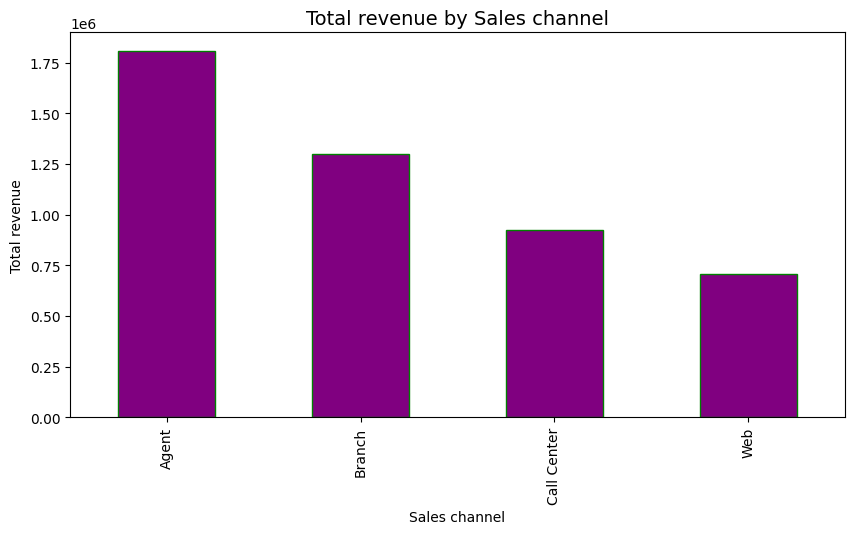

In [231]:
# Visualization of the data
plt.figure(figsize=(10, 5))
summary_table['total_claim_amount'].plot(kind='bar', color='purple', edgecolor= 'green')
plt.title('Total revenue by Sales channel', fontsize = 14)
plt.xlabel('Sales channel', fontsize = 10)
plt.ylabel('Total revenue', fontsize = 10)
plt.show()

2. Create a pivot table that shows the average customer lifetime value per gender and education level. Analyze the resulting table to draw insights.

In [218]:
# Creating pivot table to show the average custome lifetime value per gender and education level
avg_customer_value = round(marketing_data_df.pivot_table(index=['gender', 'education'], values='customer_lifetime_value', aggfunc='mean'), 2).sort_values(by="customer_lifetime_value", ascending=True)
avg_customer_value

customer_lifetime_value
gender education                                    
F      Doctor                                7328.00
M      Doctor                                7414.85
       Bachelor                              7703.09
F      College                               7748.31
       Bachelor                              7873.79
M      College                               8051.94
       High School or Below                  8149.19
F      Master                                8156.54
M      Master                                8168.33
F      High School or Below                  8674.72

## Bonus

You work at the customer service department and you want to know which months had the highest number of complaints by policy type category. Create a summary table showing the number of complaints by policy type and month.
Show it in a long format table.

*In data analysis, a long format table is a way of structuring data in which each observation or measurement is stored in a separate row of the table. The key characteristic of a long format table is that each column represents a single variable, and each row represents a single observation of that variable.*

*More information about long and wide format tables here: https://www.statology.org/long-vs-wide-data/*

In [241]:
marketing_data_df.head()

,customer,state,customer_lifetime_value,response,coverage,education,effective_to_date,employment_status,gender,income,...,policy_type,policy,renew_offer_type,sales_channel,total_claim_amount,vehicle_class,vehicle_size,vehicle_type,month,Month
0,DK49336,Arizona,4809,No,Basic,College,1970-01-01 00:00:00.000000018,Employed,M,48029,...,Corporate Auto,Corporate L3,Offer3,Agent,292,Four-Door Car,Medsize,A,2,1
1,KX64629,California,2228,No,Basic,College,1970-01-01 00:00:00.000000018,Unemployed,F,0,...,Personal Auto,Personal L3,Offer4,Call Center,744,Four-Door Car,Medsize,A,1,1
2,LZ68649,Washington,14947,No,Basic,Bachelor,1970-01-01 00:00:00.000000010,Employed,M,22139,...,Personal Auto,Personal L3,Offer3,Call Center,480,SUV,Medsize,A,2,1
3,XL78013,Oregon,22332,Yes,Extended,College,1970-01-01 00:00:00.000000011,Employed,M,49078,...,Corporate Auto,Corporate L3,Offer2,Branch,484,Four-Door Car,Medsize,A,1,1
4,QA50777,Oregon,9025,No,Premium,Bachelor,1970-01-01 00:00:00.000000017,Medical Leave,F,23675,...,Personal Auto,Personal L2,Offer1,Branch,707,Four-Door Car,Medsize,A,1,1


In [237]:
marketing_data_df['effective_to_date'] = pd.to_datetime(marketing_data_df['effective_to_date'], format="mixed")

# Verifing the dtype
display(marketing_data_df["effective_to_date"])

0       1970-01-01 00:00:00.000000018
1       1970-01-01 00:00:00.000000018
2       1970-01-01 00:00:00.000000010
3       1970-01-01 00:00:00.000000011
4       1970-01-01 00:00:00.000000017
                     ...             
10905   1970-01-01 00:00:00.000000019
10906   1970-01-01 00:00:00.000000006
10907   1970-01-01 00:00:00.000000006
10908   1970-01-01 00:00:00.000000013
10909   1970-01-01 00:00:00.000000008
Name: effective_to_date, Length: 10910, dtype: datetime64[ns]

In [240]:
# Extracting the months 
marketing_data_df['Month'] = marketing_data_df['effective_to_date'].dt.month
marketing_data_df[["Month"]].sort_index(ascending=True)

,Month
0,1
1,1
2,1
3,1
4,1
...,...
10905,1
10906,1
10907,1
10908,1


In [253]:
# Creating format table for complaints per month
complaint_summary_table = pd.melt(marketing_data_df, id_vars=['month', 'policy_type'], value_vars = 'number_of_open_complaints', var_name='metric', value_name='complaints_count')
complaint_summary_table

,month,policy_type,metric,complaints_count
0,2,Corporate Auto,number_of_open_complaints,0
1,1,Personal Auto,number_of_open_complaints,0
2,2,Personal Auto,number_of_open_complaints,0
3,1,Corporate Auto,number_of_open_complaints,0
4,1,Personal Auto,number_of_open_complaints,0
...,...,...,...,...
10905,1,Personal Auto,number_of_open_complaints,0
10906,1,Personal Auto,number_of_open_complaints,0
10907,2,Corporate Auto,number_of_open_complaints,0
10908,2,Personal Auto,number_of_open_complaints,4
